# Function Spaces: L2, H1, and Hilbert Spaces

This notebook accompanies Chapter 2 (Representing Functions and Fields) and prepares its section on inner products, projection, and orthogonality.

A taut string on $[0, 1]$ is pinned at both ends and carries a load $f(x)$.
Its displacement $u(x)$ solves

$$-u''(x) = f(x), \qquad u(0) = u(1) = 0.$$

The chapter measures the error of an approximate displacement with a norm, and it finds the closest approximation by projection.
Both operations need a set of functions on which the norm is finite and inside which limits of approximations stay.
A point load bends the string into a corner, a load can jump, and a function can grow without bound near one end.
Which of these functions belong to the set, and which norm decides?


In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

_d = pathlib.Path.cwd()
for cand in (_d, *_d.parents):
    if (cand / "sciml_style.mplstyle").exists():
        plt.style.use(str(cand / "sciml_style.mplstyle"))
        break
plt.rcParams.update({"text.usetex": False, "font.family": "sans-serif"})

BLUE, ORANGE, GREEN, RED = "#2997c8", "#ef8354", "#4f9d69", "#d95d5d"
INK, MUTED, YELLOW = "#1d252c", "#687078", "#f0c84b"

# grid spacing 5e-6; x = 1/2 is a grid point
x = np.linspace(0.0, 1.0, 200001)

def l2(f):
    return np.sqrt(np.trapezoid(f**2, x))

def sine_coeff(g, k):
    # b_k = 2 int_0^1 g sin(k pi x) dx, so that g = sum b_k sin(k pi x)
    return 2 * np.trapezoid(g * np.sin(k * np.pi * x), x)

## $L^2$, finite energy in value

The first measure of a function is the size of its values.
The $L^2$ norm squares the values, integrates, and takes the root,

$$\|f\|_{L^2} = \left(\int_0^1 f(x)^2 \, dx\right)^{1/2}, \qquad \langle f, g \rangle = \int_0^1 f(x)\, g(x) \, dx,$$

and the inner product on the right produces the norm through $\langle f, f \rangle = \|f\|_{L^2}^2$.
The space $L^2(0,1)$ contains every measurable function on $(0,1)$ whose squared integral is finite.

The unit step $H$, which jumps from $0$ to $1$ at $x = 1/2$, belongs to $L^2$ with $\|H\|_{L^2} = \sqrt{1/2} = 0.7071$.
A member of $L^2$ can also be unbounded.
The function $x^{-1/3}$ grows without bound near $x = 0$, yet $\int_0^1 x^{-2/3} \, dx = 3$, so $\|x^{-1/3}\|_{L^2} = \sqrt{3} = 1.7321$.
The function $x^{-1/2}$ grows a little faster near zero.
Its square $1/x$ integrates from $\epsilon$ to $1$ to $\ln(1/\epsilon)$, which is $4.61$ at $\epsilon = 10^{-2}$ and $18.42$ at $\epsilon = 10^{-8}$ and grows without bound as $\epsilon \to 0$.
So $x^{-1/2}$ is outside $L^2$.
The power $x^{-p}$ belongs to $L^2(0,1)$ when $p < 1/2$ and fails when $p \geq 1/2$.

The inner product of the step with $x^{-1/3}$ is $\int_{1/2}^1 x^{-1/3} \, dx = 0.5551$.
The Cauchy-Schwarz inequality bounds it by the product of the norms, $0.7071 \times 1.7321 = 1.2247$.

Two functions that differ at one point have $L^2$ distance zero.
Take $f(x) = x$, and let $g$ agree with $f$ except at $x = 1/2$, where $g(1/2) = 5$.
The squared difference is zero except at one point, and its integral is zero.
A trapezoid sum on a grid of spacing $h$ that contains $x = 1/2$ gives that point the weight $h$, so the sampled distance is $5\sqrt{h}$.
It falls from $1.58$ at $h = 0.1$ to $0.05$ at $h = 10^{-4}$.
In $L^2$, $f$ and $g$ are the same element.
An element of $L^2$ therefore has no value at a point, since its value at $x = 1/2$ can change without changing the element.


||H||_L2 = 0.7071
int_0^1 x^(-2/3) dx = 3.0000,  ||x^(-1/3)||_L2 = 1.7321
int_eps^1 dx/x at eps = 1e-02: 4.61
int_eps^1 dx/x at eps = 1e-04: 9.21
int_eps^1 dx/x at eps = 1e-08: 18.42
<H, x^(-1/3)> = 0.5551,  ||H|| ||x^(-1/3)|| = 1.2247
h = 1e-01: sampled ||f - g|| = 1.5811
h = 1e-02: sampled ||f - g|| = 0.5000
h = 1e-03: sampled ||f - g|| = 0.1581
h = 1e-04: sampled ||f - g|| = 0.0500


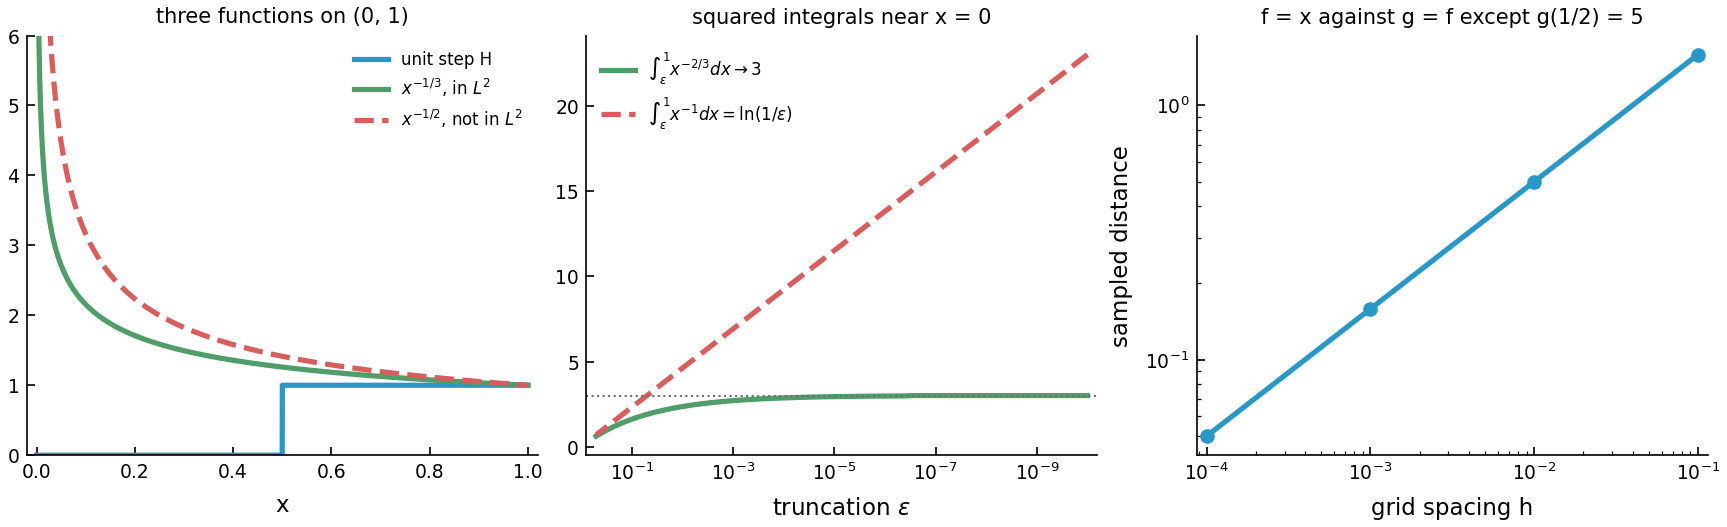

In [2]:
step = np.where(x < 0.5, 0.0, 1.0)
print(f"||H||_L2 = {l2(step):.4f}")
I13, _ = quad(lambda t: t**(-2/3), 0, 1, limit=200)
print(f"int_0^1 x^(-2/3) dx = {I13:.4f},  ||x^(-1/3)||_L2 = {np.sqrt(I13):.4f}")
for eps in (1e-2, 1e-4, 1e-8):
    I, _ = quad(lambda t: 1 / t, eps, 1, limit=200)
    print(f"int_eps^1 dx/x at eps = {eps:.0e}: {I:.2f}")
ip, _ = quad(lambda t: t**(-1/3), 0.5, 1)
print(f"<H, x^(-1/3)> = {ip:.4f},  ||H|| ||x^(-1/3)|| = {l2(step) * np.sqrt(I13):.4f}")

hs, dist = [], []
for N in (10, 100, 1000, 10000):
    xg = np.linspace(0, 1, N + 1)
    d = np.zeros_like(xg)
    d[N // 2] = 5.0          # g - f is nonzero only at x = 1/2
    hs.append(1 / N)
    dist.append(np.sqrt(np.trapezoid(d**2, xg)))
    print(f"h = {1/N:.0e}: sampled ||f - g|| = {dist[-1]:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.5))
xp = np.linspace(1e-4, 1, 4000)
ax[0].plot(xp, np.where(xp < 0.5, 0.0, 1.0), color=BLUE, lw=2.5, label="unit step H")
ax[0].plot(xp, xp**(-1/3), color=GREEN, lw=2.5, label=r"$x^{-1/3}$, in $L^2$")
ax[0].plot(xp, xp**(-1/2), color=RED, lw=2.5, ls="--", label=r"$x^{-1/2}$, not in $L^2$")
ax[0].set_ylim(0, 6)
ax[0].set_xlabel("x")
ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("three functions on (0, 1)", fontsize=10)

eps = np.logspace(-10, -0.3, 60)
ax[1].semilogx(eps, [quad(lambda t: t**(-2/3), e, 1)[0] for e in eps], color=GREEN, lw=2.5,
               label=r"$\int_\epsilon^1 x^{-2/3}dx \to 3$")
ax[1].semilogx(eps, [quad(lambda t: 1 / t, e, 1, limit=200)[0] for e in eps], color=RED, lw=2.5,
               ls="--", label=r"$\int_\epsilon^1 x^{-1}dx = \ln(1/\epsilon)$")
ax[1].axhline(3, color=MUTED, lw=1, ls=":")
ax[1].invert_xaxis()
ax[1].set_xlabel(r"truncation $\epsilon$")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("squared integrals near x = 0", fontsize=10)

ax[2].loglog(hs, dist, "o-", color=BLUE, lw=2.5)
ax[2].set_xlabel("grid spacing h")
ax[2].set_ylabel("sampled distance")
ax[2].set_title("f = x against g = f except g(1/2) = 5", fontsize=10)
plt.show()

## $H^1$, finite energy in value and slope

A displacement also has a slope, and $L^2$ measures none of it.
The $H^1$ norm adds the squared slope to the squared value,

$$\|u\|_{H^1} = \left(\|u\|_{L^2}^2 + \|u'\|_{L^2}^2\right)^{1/2}, \qquad \langle u, v \rangle_{H^1} = \int_0^1 \left(u v + u' v'\right) dx.$$

Here $u'$ is the weak derivative of the chapter's section on completeness, so a function with a corner has a slope defined everywhere except at the corner.
The space $H^1(0,1)$ contains the functions of $L^2$ whose weak derivative is also in $L^2$.

The pinned string's displacements form $H^1_0(0,1)$, the members of $H^1$ with $u(0) = u(1) = 0$.
On $H^1_0$ the slope term alone is a norm, the seminorm $|u|_{H^1} = \|u'\|_{L^2}$.
A pinned function with zero slope is a constant that vanishes at the ends, so only the zero function has $|u|_{H^1} = 0$.
The Poincaré inequality $\|u\|_{L^2} \leq |u|_{H^1} / \pi$ states the same fact with a constant, and $\sin(\pi x)$ attains it.
For a string of unit tension, half the square of the seminorm is the elastic energy, $E(u) = \tfrac12 \int_0^1 u'^2 \, dx$.

The point-load corner $u = \min(x, 1-x)/2$ lies in $H^1_0$ (top left panel).
Its slope is a step from $+1/2$ to $-1/2$, whose square integrates to $1/4$.
So $|u|_{H^1} = 0.5$, the elastic energy is $0.125$, and $\pi \|u\|_{L^2} / |u|_{H^1} = 0.9069$ sits below the Poincaré bound of $1$.

The step $H$ is outside $H^1$.
Its derivative is a delta at the jump, and the delta is not a square-integrable function.
Ramps approximating the step show the failure in numbers (top right panel).
A ramp that climbs from $0$ to $1$ across width $w$ has slope $1/w$ on that interval, so its slope-squared integral is $1/w$.
This integral is $5$ at $w = 0.2$ and $100$ at $w = 0.01$, and it grows without bound as the ramp approaches the step (bottom left panel).

In one dimension every $H^1$ function is continuous.
For $x < y$, the Cauchy-Schwarz inequality gives

$$|u(y) - u(x)| = \left|\int_x^y u'(s) \, ds\right| \leq \sqrt{y - x}\, \|u'\|_{L^2},$$

so nearby points have nearby values, and every element of $H^1$ has a continuous representative with well-defined point values.
The bound needs only a square-integrable slope.
The function $u = x^{3/4} - x$ has the slope $\tfrac34 x^{-1/4} - 1$, which is unbounded at $x = 0$, and yet $|u|_{H^1}^2 = 0.125$.
Over $20000$ random pairs of points, the largest ratio of $|u(y) - u(x)|$ to $\sqrt{|y-x|}\,|u|_{H^1}$ is $0.7028$ (bottom right panel).

The continuity bound holds in one dimension only.
On the disk of radius $1/2$ in the plane, $u = \ln \ln (1/r)$ has $\int |\nabla u|^2 \, dA = 2\pi / \ln 2 = 9.0647$ and a finite $L^2$ norm, so it lies in $H^1$, and it is unbounded at the center.
In two or more dimensions an $H^1$ function need not be bounded or continuous.


corner: ||u||_L2 = 0.1443, |u|_H1 = 0.5000, ||u||_H1 = 0.5204
corner: elastic energy = 0.1250, pi ||u|| / |u|_H1 = 0.9069
ramp w = 0.200: int (u')^2 dx = 5.00   1/w = 5.00
ramp w = 0.100: int (u')^2 dx = 10.00   1/w = 10.00
ramp w = 0.050: int (u')^2 dx = 20.00   1/w = 20.00
ramp w = 0.020: int (u')^2 dx = 50.00   1/w = 50.00
ramp w = 0.010: int (u')^2 dx = 100.00   1/w = 100.00
ramp w = 0.005: int (u')^2 dx = 200.00   1/w = 200.00
log-log slope of int (u')^2 against w: -1.000
u = x^(3/4) - x: |u|_H1^2 = 0.1250, max ratio over 20000 pairs = 0.7028
u = ln ln(1/r) on r < 1/2: int |grad u|^2 dA = 9.0647


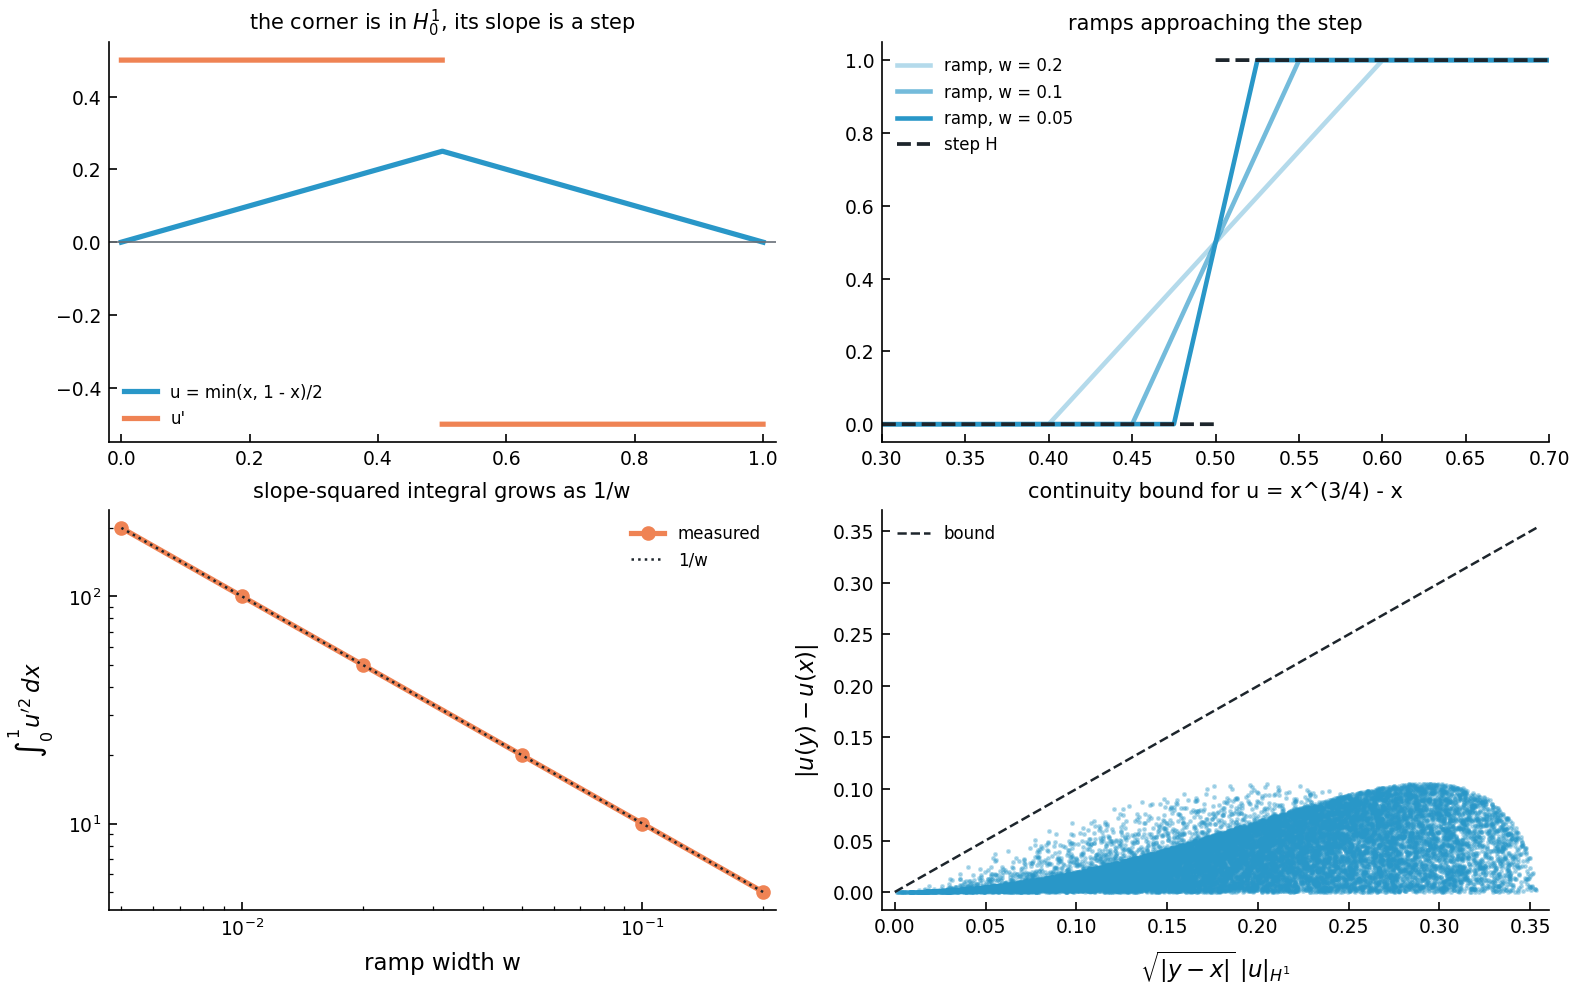

In [3]:
corner = np.minimum(x, 1 - x) / 2
dcorner = np.where(x < 0.5, 0.5, -0.5)
semi = l2(dcorner)
print(f"corner: ||u||_L2 = {l2(corner):.4f}, |u|_H1 = {semi:.4f}, ||u||_H1 = {np.sqrt(l2(corner)**2 + semi**2):.4f}")
print(f"corner: elastic energy = {0.5 * semi**2:.4f}, pi ||u|| / |u|_H1 = {np.pi * l2(corner) / semi:.4f}")

def ramp(w):
    return np.clip((x - (0.5 - w / 2)) / w, 0.0, 1.0)

ws = np.array([0.2, 0.1, 0.05, 0.02, 0.01, 0.005])
energy = []
for w in ws:
    r = ramp(w)
    energy.append(np.sum(np.diff(r)**2 / np.diff(x)))   # int (r')^2 dx for piecewise-linear r
    print(f"ramp w = {w:.3f}: int (u')^2 dx = {energy[-1]:.2f}   1/w = {1/w:.2f}")
print(f"log-log slope of int (u')^2 against w: {np.polyfit(np.log(ws), np.log(energy), 1)[0]:.3f}")

u3 = lambda t: t**0.75 - t
semi3 = np.sqrt(quad(lambda t: (0.75 * t**-0.25 - 1)**2, 0, 1)[0])
rng = np.random.default_rng(1)
pairs = rng.uniform(0, 1, size=(20000, 2))
lhs = np.abs(u3(pairs[:, 1]) - u3(pairs[:, 0]))
rhs = np.sqrt(np.abs(pairs[:, 1] - pairs[:, 0])) * semi3
print(f"u = x^(3/4) - x: |u|_H1^2 = {semi3**2:.4f}, max ratio over 20000 pairs = {np.max(lhs / rhs):.4f}")
Idisk = 2 * np.pi * quad(lambda s: 1 / s**2, np.log(2), np.inf)[0]   # s = ln(1/r)
print(f"u = ln ln(1/r) on r < 1/2: int |grad u|^2 dA = {Idisk:.4f}")

fig, ax = plt.subplots(2, 2, figsize=(10.5, 6.6))
ax[0, 0].plot(x, corner, color=BLUE, lw=2.5, label="u = min(x, 1 - x)/2")
ax[0, 0].plot(x[x < 0.5], dcorner[x < 0.5], color=ORANGE, lw=2.5, label="u'")
ax[0, 0].plot(x[x > 0.5], dcorner[x > 0.5], color=ORANGE, lw=2.5)
ax[0, 0].axhline(0, color=MUTED, lw=0.8)
ax[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
ax[0, 0].set_title(r"the corner is in $H^1_0$, its slope is a step", fontsize=10)

for w, a in zip((0.2, 0.1, 0.05), (0.35, 0.65, 1.0)):
    ax[0, 1].plot(x, ramp(w), color=BLUE, lw=2.2, alpha=a, label=f"ramp, w = {w}")
ax[0, 1].plot(x[x < 0.5], step[x < 0.5], color=INK, lw=1.8, ls="--")
ax[0, 1].plot(x[x > 0.5], step[x > 0.5], color=INK, lw=1.8, ls="--", label="step H")
ax[0, 1].set_xlim(0.3, 0.7)
ax[0, 1].legend(frameon=False, fontsize=8, loc="upper left")
ax[0, 1].set_title("ramps approaching the step", fontsize=10)

ax[1, 0].loglog(ws, energy, "o-", color=ORANGE, lw=2.5, label="measured")
ax[1, 0].loglog(ws, 1 / ws, color=INK, lw=1.2, ls=":", label="1/w")
ax[1, 0].set_xlabel("ramp width w")
ax[1, 0].set_ylabel(r"$\int_0^1 u'^2\,dx$")
ax[1, 0].legend(frameon=False, fontsize=8)
ax[1, 0].set_title("slope-squared integral grows as 1/w", fontsize=10)

ax[1, 1].scatter(rhs, lhs, s=2, color=BLUE, alpha=0.3)
lim = rhs.max()
ax[1, 1].plot([0, lim], [0, lim], color=INK, lw=1.2, ls="--", label="bound")
ax[1, 1].set_xlabel(r"$\sqrt{|y-x|}\;|u|_{H^1}$")
ax[1, 1].set_ylabel(r"$|u(y)-u(x)|$")
ax[1, 1].legend(frameon=False, fontsize=8)
ax[1, 1].set_title("continuity bound for u = x^(3/4) - x", fontsize=10)
plt.show()

## Wiggles

The $L^2$ norm cannot tell a slow shape from a fast wiggle of the same size.
The string's modes $e_k(x) = \sqrt{2}\sin(k\pi x)$ are orthonormal in $L^2$, so every mode has $\|e_k\|_{L^2} = 1$.
Their slopes are $\sqrt{2}\,k\pi\cos(k\pi x)$, and the slope norm grows with the mode number, $|e_k|_{H^1} = k\pi$.
Mode $10$ has the $L^2$ norm of mode $1$, a slope norm ten times larger ($31.42$ against $3.14$), and one hundred times the elastic energy.
The lab below draws the mode beside its slope.


<iframe srcdoc="&lt;!DOCTYPE html&gt;&lt;html&gt;&lt;head&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1&quot;&gt;&lt;style&gt;:root { --paper: #fbfbf7; --ink: #1d252c; --muted: #687078; --grid: #e7e7e2; --blue: #2997c8; --orange: #ef8354; --green: #4f9d69; --red: #d95d5d; --yellow: #f0c84b; }
@media (prefers-color-scheme: dark) { :root { --paper: #1e1e1e; --ink: #e8e8e8; --muted: #a0a0a0; --grid: #3a3a3a; --blue: #6fbbdd; --orange: #f0997b; --green: #5dcaa5; --red: #e88a8a; --yellow: #fac775; } }
* { box-sizing: border-box; }
body {
  margin: 0; padding: 14px 16px; background: var(--paper); color: var(--ink);
  font-family: -apple-system, BlinkMacSystemFont, &quot;Segoe UI&quot;, Roboto, Inter, sans-serif;
  font-size: 14px; line-height: 1.5;
}
.lab { max-width: 760px; margin: 0 auto; }
.lab-title { font-size: 16px; font-weight: 650; margin: 0 0 2px; }
.lab-sub { font-size: 12.5px; color: var(--muted); margin: 0 0 10px; }
svg.plot { width: 100%; display: block; background: var(--paper); }
.grid-line { stroke: var(--grid); stroke-width: 1; }
.axis-line { stroke: var(--muted); stroke-width: 1.2; }
.axis-label { fill: var(--muted); font-size: 11px; }
.slider-row { display: flex; align-items: center; gap: 10px; margin: 6px 0; }
.slider-row &gt; span { font-size: 13px; white-space: nowrap; min-width: 110px; }
.slider-row input[type=range] { flex: 1; accent-color: var(--slider-color, var(--blue)); }
.slider-row output {
  font-variant-numeric: tabular-nums; font-size: 13px; font-weight: 600;
  min-width: 52px; text-align: right;
}
.readout-row { display: flex; gap: 10px; flex-wrap: wrap; margin: 8px 0 2px; }
.readout {
  background: color-mix(in srgb, var(--ink) 6%, var(--paper));
  border-radius: 8px; padding: 5px 12px;
}
.readout .label { display: block; font-size: 10.5px; color: var(--muted); }
.readout .num {
  font-size: 15px; font-weight: 650; font-variant-numeric: tabular-nums;
}
.btn-row { display: flex; gap: 8px; margin: 8px 0; flex-wrap: wrap; }
.btn-row button {
  font: inherit; font-size: 12.5px; padding: 4px 12px; cursor: pointer;
  color: var(--ink); background: transparent;
  border: 1px solid var(--grid); border-radius: 999px;
}
.btn-row button.selected { border-color: var(--blue); color: var(--blue); font-weight: 650; }
.lab-note { font-size: 12px; color: var(--muted); margin: 8px 0 0; }
.float-label {
  position: absolute; top: 10px; right: 12px; font-size: 11px;
  color: var(--muted); letter-spacing: .04em;
}
.plot-wrap { position: relative; }
&lt;/style&gt;&lt;script&gt;
const L = (function () {
  const NS = &quot;http://www.w3.org/2000/svg&quot;;
  function el(tag, attrs, parent) {
    const node = document.createElementNS(NS, tag);
    for (const k in attrs) node.setAttribute(k, attrs[k]);
    if (parent) parent.appendChild(node);
    return node;
  }
  function scale(a, b, pa, pb) { return v =&gt; pa + (v - a) * (pb - pa) / (b - a); }
  function pathd(fn, X, Y, n) {
    n = n || 241;
    let d = &quot;&quot;;
    for (let i = 0; i &lt; n; i++) {
      const x = i / (n - 1);
      d += (i ? &quot; L&quot; : &quot;M&quot;) + X(x).toFixed(2) + &quot; &quot; + Y(fn(x)).toFixed(2);
    }
    return d;
  }
  function curve(svg, fn, X, Y, opts) {
    opts = opts || {};
    // Colors go through the style attribute: CSS var() is not valid in
    // SVG presentation attributes, but works in inline style.
    const style = &quot;stroke:&quot; + (opts.stroke || &quot;var(--blue)&quot;)
      + &quot;;stroke-width:&quot; + (opts.width || 3)
      + (opts.dash ? &quot;;stroke-dasharray:&quot; + opts.dash : &quot;&quot;)
      + &quot;;opacity:&quot; + (opts.opacity === undefined ? 1 : opts.opacity)
      + &quot;;stroke-linecap:round;stroke-linejoin:round&quot;;
    return el(&quot;path&quot;, { d: pathd(fn, X, Y, opts.n), fill: &quot;none&quot;, style: style }, svg);
  }
  function axes(svg, X, Y, opts) {
    opts = opts || {};
    const g = el(&quot;g&quot;, {}, svg);
    const nx = opts.nx || 8, ny = opts.ny || 4;
    for (let i = 0; i &lt;= nx; i++) {
      const px = X(i / nx);
      el(&quot;line&quot;, { x1: px, y1: Y(opts.yMax), x2: px, y2: Y(-opts.yMax), class: &quot;grid-line&quot; }, g);
    }
    for (let j = 0; j &lt;= ny; j++) {
      const u = -opts.yMax + 2 * opts.yMax * j / ny;
      el(&quot;line&quot;, { x1: X(0), y1: Y(u), x2: X(1), y2: Y(u), class: &quot;grid-line&quot; }, g);
    }
    el(&quot;line&quot;, { x1: X(0), y1: Y(0), x2: X(1), y2: Y(0), class: &quot;axis-line&quot; }, g);
    el(&quot;line&quot;, { x1: X(0), y1: Y(opts.yMax), x2: X(0), y2: Y(-opts.yMax), class: &quot;axis-line&quot; }, g);
    const lx = el(&quot;text&quot;, { x: X(1) - 4, y: Y(0) - 6, class: &quot;axis-label&quot;, &quot;text-anchor&quot;: &quot;end&quot; }, g);
    lx.textContent = opts.xlabel || &quot;x&quot;;
    const ly = el(&quot;text&quot;, { x: X(0) + 6, y: Y(opts.yMax) + 12, class: &quot;axis-label&quot; }, g);
    ly.textContent = opts.ylabel || &quot;&quot;;
    return g;
  }
  function fmt(v, d) { const s = v.toFixed(d === undefined ? 2 : d); return s === &quot;-0.00&quot; ? &quot;0.00&quot; : s; }
  return { el, scale, pathd, curve, axes, fmt, NS };
})();
&lt;/script&gt;&lt;/head&gt;&lt;body&gt;&lt;div class=&quot;lab&quot;&gt;&lt;p class=&quot;lab-title&quot;&gt;One unit of L2, any amount of slope&lt;/p&gt;&lt;p class=&quot;lab-sub&quot;&gt;Raise k. The L2 readout stays at 1 while the slope norm grows as k times pi.&lt;/p&gt;
&lt;div style=&quot;display:flex; gap:10px;&quot;&gt;
  &lt;div style=&quot;flex:1&quot;&gt;&lt;svg id=&quot;wg-f&quot; class=&quot;plot&quot; viewBox=&quot;0 0 355 240&quot;&gt;&lt;/svg&gt;&lt;/div&gt;
  &lt;div style=&quot;flex:1&quot;&gt;&lt;svg id=&quot;wg-d&quot; class=&quot;plot&quot; viewBox=&quot;0 0 355 240&quot;&gt;&lt;/svg&gt;&lt;/div&gt;
&lt;/div&gt;
&lt;div class=&quot;slider-row&quot; style=&quot;--slider-color: var(--blue)&quot;&gt;&lt;span&gt;mode number k&lt;/span&gt;&lt;input id=&quot;wg-k&quot; type=&quot;range&quot; min=&quot;1&quot; max=&quot;12&quot; step=&quot;1&quot; value=&quot;3&quot;&gt;&lt;output id=&quot;wg-kv&quot;&gt;3&lt;/output&gt;&lt;/div&gt;
&lt;div class=&quot;readout-row&quot;&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;L&amp;#178; norm &amp;#8214;e&lt;sub&gt;k&lt;/sub&gt;&amp;#8214;&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;wg-l2&quot;&gt;1.000&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;H&amp;#185; seminorm |e&lt;sub&gt;k&lt;/sub&gt;|, equal to k&amp;pi;&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;wg-h1&quot;&gt;9.42&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;elastic energy &amp;frac12;|e&lt;sub&gt;k&lt;/sub&gt;|&amp;#178;&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;wg-en&quot;&gt;44.4&lt;/span&gt;&lt;/div&gt;
&lt;/div&gt;
&lt;p class=&quot;lab-note&quot;&gt;Left, the mode e&lt;sub&gt;k&lt;/sub&gt;(x) = &amp;radic;2 sin(k&amp;pi;x) on a fixed axis. Right, its slope in orange on an axis fifty times taller. Both norms come from a midpoint sum over 4000 points.&lt;/p&gt;
&lt;script&gt;
(function(){
  const svgF = document.getElementById(&quot;wg-f&quot;), svgD = document.getElementById(&quot;wg-d&quot;);
  const XF = L.scale(0, 1, 40, 345), YF = L.scale(-1.6, 1.6, 226, 14);
  const XD = L.scale(0, 1, 40, 345), YD = L.scale(-60, 60, 226, 14);
  L.axes(svgF, XF, YF, {yMax: 1.6, xlabel: &quot;x&quot;, ylabel: &quot;e_k&quot;});
  L.axes(svgD, XD, YD, {yMax: 60, xlabel: &quot;x&quot;, ylabel: &quot;e_k&#x27;&quot;});
  const gF = L.el(&quot;g&quot;, {}, svgF), gD = L.el(&quot;g&quot;, {}, svgD);
  let k = 3;
  function redraw(){
    gF.innerHTML = &quot;&quot;; gD.innerHTML = &quot;&quot;;
    const e = t =&gt; Math.SQRT2 * Math.sin(k * Math.PI * t);
    const de = t =&gt; Math.SQRT2 * k * Math.PI * Math.cos(k * Math.PI * t);
    L.curve(gF, e, XF, YF, {stroke: &quot;var(--blue)&quot;, width: 2.5, n: 801});
    L.curve(gD, de, XD, YD, {stroke: &quot;var(--orange)&quot;, width: 2.5, n: 801});
    let a = 0, b = 0;
    const n = 4000;
    for (let i = 0; i &lt; n; i++) {
      const t = (i + 0.5) / n;
      a += e(t) ** 2 / n;
      b += de(t) ** 2 / n;
    }
    document.getElementById(&quot;wg-l2&quot;).textContent = Math.sqrt(a).toFixed(3);
    document.getElementById(&quot;wg-h1&quot;).textContent = Math.sqrt(b).toFixed(2);
    document.getElementById(&quot;wg-en&quot;).textContent = (0.5 * b).toFixed(1);
  }
  document.getElementById(&quot;wg-k&quot;).addEventListener(&quot;input&quot;, ev =&gt; {
    k = parseInt(ev.target.value);
    document.getElementById(&quot;wg-kv&quot;).textContent = k;
    redraw();
  });
  redraw();
})();
&lt;/script&gt;&lt;/div&gt;&lt;/body&gt;&lt;/html&gt;" style="width:100%;height:470px;border:none;overflow:hidden;" scrolling="no" loading="lazy"></iframe>

In [4]:
for k in (1, 2, 3, 5, 10):
    e = np.sqrt(2) * np.sin(k * np.pi * x)
    de = np.sqrt(2) * k * np.pi * np.cos(k * np.pi * x)
    print(f"k = {k:2d}: ||e_k||_L2 = {l2(e):.4f}, |e_k|_H1 = {l2(de):.4f}, "
          f"k pi = {k*np.pi:.4f}, energy = {0.5*l2(de)**2:.2f}")

k =  1: ||e_k||_L2 = 1.0000, |e_k|_H1 = 3.1416, k pi = 3.1416, energy = 4.93
k =  2: ||e_k||_L2 = 1.0000, |e_k|_H1 = 6.2832, k pi = 6.2832, energy = 19.74
k =  3: ||e_k||_L2 = 1.0000, |e_k|_H1 = 9.4248, k pi = 9.4248, energy = 44.41
k =  5: ||e_k||_L2 = 1.0000, |e_k|_H1 = 15.7080, k pi = 15.7080, energy = 123.37
k = 10: ||e_k||_L2 = 1.0000, |e_k|_H1 = 31.4159, k pi = 31.4159, energy = 493.48


## Hilbert spaces

Every example so far is a single function, and the chapter also needs limits of sequences of functions.
Consider the continuous functions on $[0,1]$ with the $L^2$ distance.
The ramp of width $w = 1/n$ differs from the step only across its transition, where the gap rises linearly to $1/2$ and falls back.
The squared gap integrates to $w/12$, so the distance from ramp to step is $\sqrt{w/12}$, which is $0.2041$ at $n = 2$ and $0.0255$ at $n = 128$.
By the triangle inequality, two ramps are no farther apart than the sum of their distances to the step, and the ramps of width $1/8$ and $1/32$ lie $0.0765$ apart.
A sequence whose terms come arbitrarily close to one another is a Cauchy sequence.
Every ramp is continuous, and the $L^2$ limit of the ramps is the step, which is not.
The continuous functions with the $L^2$ distance lack the limit of one of their own Cauchy sequences.

A space is complete when every Cauchy sequence in it converges to a member of the space.
A Hilbert space is an inner-product space that is complete in the norm its inner product defines.
$\mathbb{R}^n$ with the dot product is a Hilbert space.
So are $L^2(0,1)$ with $\int f g \, dx$, $H^1(0,1)$ with $\int (u v + u' v') \, dx$, and $H^1_0(0,1)$ with $\int u' v' \, dx$.
The continuous functions with the sup norm are complete, and the sup norm comes from no inner product, so that space is complete without being a Hilbert space.

The spaces nest, $H^1_0 \subset H^1 \subset L^2$ (left panel below).
The mode $\sin(\pi x)$ and the corner lie in $H^1_0$.
The ramp $u = x$ lies in $H^1$ and outside $H^1_0$, because $u(1) = 1$.
The step and $x^{-1/3}$ lie in $L^2$ and outside $H^1$, and $x^{-1/2}$ lies outside all three.

Projection needs completeness.
Take trial shapes $v_1, v_2, \dots$ in a subspace $V$ whose distances to a target $u$ approach the smallest possible distance.
The parallelogram law makes this minimizing sequence Cauchy.
Completeness places its limit in the space, and when $V$ is closed the limit also stays in $V$.
That limit is the closest point of $V$ to $u$, and the projection theorem needs both hypotheses to guarantee it.


n =   2, w = 0.5000: ||ramp - H||_L2 = 0.2041   sqrt(w/12) = 0.2041
n =   8, w = 0.1250: ||ramp - H||_L2 = 0.1021   sqrt(w/12) = 0.1021
n =  32, w = 0.0312: ||ramp - H||_L2 = 0.0510   sqrt(w/12) = 0.0510
n = 128, w = 0.0078: ||ramp - H||_L2 = 0.0255   sqrt(w/12) = 0.0255
||ramp(1/8) - ramp(1/32)||_L2 = 0.0765


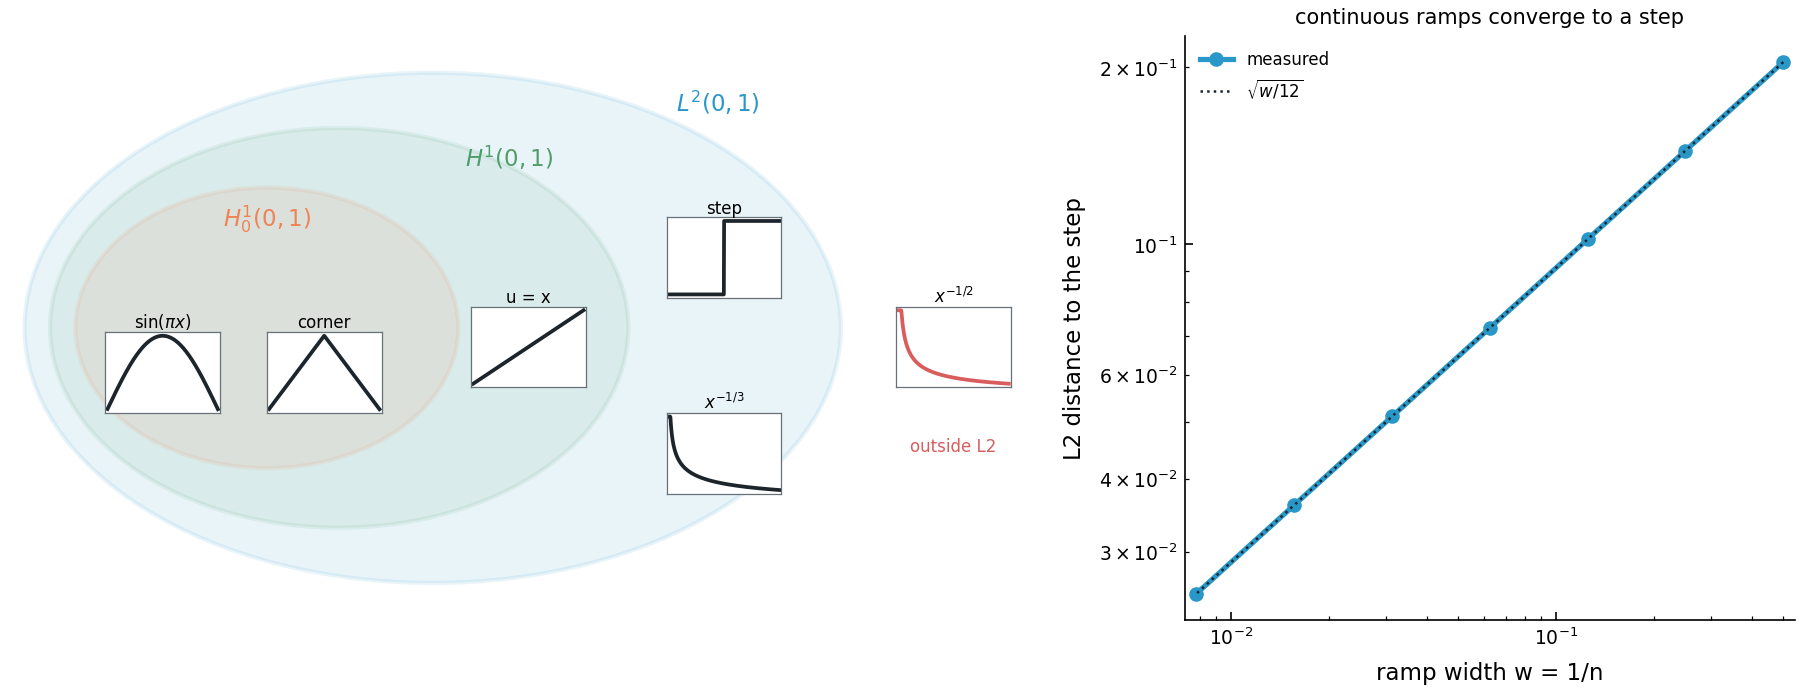

In [5]:
from matplotlib.patches import Ellipse

for n in (2, 8, 32, 128):
    w = 1 / n
    print(f"n = {n:3d}, w = {w:.4f}: ||ramp - H||_L2 = {l2(ramp(w) - step):.4f}   sqrt(w/12) = {np.sqrt(w/12):.4f}")
print(f"||ramp(1/8) - ramp(1/32)||_L2 = {l2(ramp(1/8) - ramp(1/32)):.4f}")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.7, 1]})
ax.set_xlim(0, 12.2)
ax.set_ylim(0, 6.4)
ax.set_aspect("equal")
ax.axis("off")
for (cx, wd, ht, col, lab, lx) in [(5.0, 9.6, 6.0, BLUE, r"$L^2(0,1)$", 8.35),
                                   (3.9, 6.8, 4.7, GREEN, r"$H^1(0,1)$", 5.9),
                                   (3.05, 4.5, 3.3, ORANGE, r"$H^1_0(0,1)$", 3.05)]:
    ax.add_patch(Ellipse((cx, 3.2), wd, ht, fc=col, alpha=0.10, ec=col, lw=2))
    ax.text(lx, 3.2 + ht / 2 - 0.45, lab, color=col, ha="center", fontsize=11)

xt = np.linspace(1e-3, 1, 400)
thumbs = [
    (1.15, 2.2, np.sin(np.pi * xt), r"$\sin(\pi x)$", INK),
    (3.05, 2.2, np.minimum(xt, 1 - xt), "corner", INK),
    (5.45, 2.5, xt, "u = x", INK),
    (7.75, 3.55, np.where(xt < 0.5, 0.0, 1.0), "step", INK),
    (7.75, 1.25, np.minimum(xt**(-1/3), 4), r"$x^{-1/3}$", INK),
    (10.45, 2.5, np.minimum(xt**(-1/2), 6), r"$x^{-1/2}$", RED),
]
for (x0, y0, fy, lab, col) in thumbs:
    ins = ax.inset_axes([x0, y0, 1.35, 0.95], transform=ax.transData)
    ins.plot(xt, fy, color=col, lw=1.8)
    ins.set_xticks([])
    ins.set_yticks([])
    ins.set_title(lab, fontsize=8, pad=2)
    for s in ins.spines.values():
        s.set_visible(True)
        s.set_color(MUTED)
        s.set_linewidth(0.6)
ax.text(11.12, 1.75, "outside L2", color=RED, ha="center", fontsize=8)

wn = 1 / np.array([2, 4, 8, 16, 32, 64, 128])
dn = [l2(ramp(w) - step) for w in wn]
ax2.loglog(wn, dn, "o-", color=BLUE, lw=2.5, label="measured")
ax2.loglog(wn, np.sqrt(wn / 12), color=INK, lw=1.2, ls=":", label=r"$\sqrt{w/12}$")
ax2.set_xlabel("ramp width w = 1/n")
ax2.set_ylabel("L2 distance to the step")
ax2.legend(frameon=False, fontsize=8)
ax2.set_title("continuous ramps converge to a step", fontsize=10)
plt.show()

## Compactness

A bounded sequence of real numbers has a convergent subsequence, and so does a bounded sequence in $\mathbb{R}^n$.
The unit ball of $L^2(0,1)$ lacks this property.
The modes $e_k$ all have norm $1$, and for $j \neq k$ orthogonality gives

$$\|e_j - e_k\|_{L^2}^2 = \|e_j\|_{L^2}^2 + \|e_k\|_{L^2}^2 = 2,$$

so every two modes lie at distance $\sqrt{2} = 1.4142$.
No subsequence of the modes is Cauchy, and none converges.

A bound on the slope restores the property.
Write $u = \sum_k c_k e_k$ in $H^1_0$, so that $\|u\|_{L^2}^2 = \sum_k c_k^2$ and $|u|_{H^1}^2 = \sum_k (k\pi)^2 c_k^2$.
If $|u|_{H^1} \leq M$, the modes beyond $K$ satisfy

$$\sum_{k > K} c_k^2 \;\leq\; \frac{1}{\big((K+1)\pi\big)^2} \sum_{k > K} (k\pi)^2 c_k^2 \;\leq\; \frac{M^2}{\big((K+1)\pi\big)^2}.$$

The tail beyond mode $K$ has $L^2$ norm at most $M/((K+1)\pi)$, and the same bound holds for every $u$ with $|u|_{H^1} \leq M$.
All energy in mode $K+1$ attains it, and at $M = 4$ and $K = 5$ that tail and the bound both equal $0.2122$.
Over $500$ random coefficient lists with random $M$ and $K$, the largest ratio of tail to bound is $0.633$ and the median is $0.327$.
So every function in this set lies within $M/((K+1)\pi)$ of the space of the first $K$ modes, and in that finite-dimensional space bounded sets are compact.
This is Rellich's theorem for the interval.
On a bounded domain $\Omega$, every sequence bounded in $H^1_0(\Omega)$ has a subsequence that converges in $L^2(\Omega)$.
The same holds for $H^1(\Omega)$ when the boundary of $\Omega$ is Lipschitz, which includes every bounded interval.
The modes $e_k$ fall outside the hypothesis, because $|e_k|_{H^1} = k\pi$ grows without bound.

The tail bound turns truncation into an approximation with a guaranteed error.
Keeping $K$ sine modes of a displacement whose elastic energy is at most $M^2/2$ leaves an $L^2$ error of at most $M/((K+1)\pi)$.
The same argument on each element of length $h$ bounds the $L^2$ error of hat interpolation by $hM/\pi$, and the same $500$ draws reach at most $0.711$ of that bound.
The lab draws a random coefficient list scaled to $|u|_{H^1} = M$, its truncation to $K$ modes, and the measured tail against the bound.


<iframe srcdoc="&lt;!DOCTYPE html&gt;&lt;html&gt;&lt;head&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1&quot;&gt;&lt;style&gt;:root { --paper: #fbfbf7; --ink: #1d252c; --muted: #687078; --grid: #e7e7e2; --blue: #2997c8; --orange: #ef8354; --green: #4f9d69; --red: #d95d5d; --yellow: #f0c84b; }
@media (prefers-color-scheme: dark) { :root { --paper: #1e1e1e; --ink: #e8e8e8; --muted: #a0a0a0; --grid: #3a3a3a; --blue: #6fbbdd; --orange: #f0997b; --green: #5dcaa5; --red: #e88a8a; --yellow: #fac775; } }
* { box-sizing: border-box; }
body {
  margin: 0; padding: 14px 16px; background: var(--paper); color: var(--ink);
  font-family: -apple-system, BlinkMacSystemFont, &quot;Segoe UI&quot;, Roboto, Inter, sans-serif;
  font-size: 14px; line-height: 1.5;
}
.lab { max-width: 760px; margin: 0 auto; }
.lab-title { font-size: 16px; font-weight: 650; margin: 0 0 2px; }
.lab-sub { font-size: 12.5px; color: var(--muted); margin: 0 0 10px; }
svg.plot { width: 100%; display: block; background: var(--paper); }
.grid-line { stroke: var(--grid); stroke-width: 1; }
.axis-line { stroke: var(--muted); stroke-width: 1.2; }
.axis-label { fill: var(--muted); font-size: 11px; }
.slider-row { display: flex; align-items: center; gap: 10px; margin: 6px 0; }
.slider-row &gt; span { font-size: 13px; white-space: nowrap; min-width: 110px; }
.slider-row input[type=range] { flex: 1; accent-color: var(--slider-color, var(--blue)); }
.slider-row output {
  font-variant-numeric: tabular-nums; font-size: 13px; font-weight: 600;
  min-width: 52px; text-align: right;
}
.readout-row { display: flex; gap: 10px; flex-wrap: wrap; margin: 8px 0 2px; }
.readout {
  background: color-mix(in srgb, var(--ink) 6%, var(--paper));
  border-radius: 8px; padding: 5px 12px;
}
.readout .label { display: block; font-size: 10.5px; color: var(--muted); }
.readout .num {
  font-size: 15px; font-weight: 650; font-variant-numeric: tabular-nums;
}
.btn-row { display: flex; gap: 8px; margin: 8px 0; flex-wrap: wrap; }
.btn-row button {
  font: inherit; font-size: 12.5px; padding: 4px 12px; cursor: pointer;
  color: var(--ink); background: transparent;
  border: 1px solid var(--grid); border-radius: 999px;
}
.btn-row button.selected { border-color: var(--blue); color: var(--blue); font-weight: 650; }
.lab-note { font-size: 12px; color: var(--muted); margin: 8px 0 0; }
.float-label {
  position: absolute; top: 10px; right: 12px; font-size: 11px;
  color: var(--muted); letter-spacing: .04em;
}
.plot-wrap { position: relative; }
&lt;/style&gt;&lt;script&gt;
const L = (function () {
  const NS = &quot;http://www.w3.org/2000/svg&quot;;
  function el(tag, attrs, parent) {
    const node = document.createElementNS(NS, tag);
    for (const k in attrs) node.setAttribute(k, attrs[k]);
    if (parent) parent.appendChild(node);
    return node;
  }
  function scale(a, b, pa, pb) { return v =&gt; pa + (v - a) * (pb - pa) / (b - a); }
  function pathd(fn, X, Y, n) {
    n = n || 241;
    let d = &quot;&quot;;
    for (let i = 0; i &lt; n; i++) {
      const x = i / (n - 1);
      d += (i ? &quot; L&quot; : &quot;M&quot;) + X(x).toFixed(2) + &quot; &quot; + Y(fn(x)).toFixed(2);
    }
    return d;
  }
  function curve(svg, fn, X, Y, opts) {
    opts = opts || {};
    // Colors go through the style attribute: CSS var() is not valid in
    // SVG presentation attributes, but works in inline style.
    const style = &quot;stroke:&quot; + (opts.stroke || &quot;var(--blue)&quot;)
      + &quot;;stroke-width:&quot; + (opts.width || 3)
      + (opts.dash ? &quot;;stroke-dasharray:&quot; + opts.dash : &quot;&quot;)
      + &quot;;opacity:&quot; + (opts.opacity === undefined ? 1 : opts.opacity)
      + &quot;;stroke-linecap:round;stroke-linejoin:round&quot;;
    return el(&quot;path&quot;, { d: pathd(fn, X, Y, opts.n), fill: &quot;none&quot;, style: style }, svg);
  }
  function axes(svg, X, Y, opts) {
    opts = opts || {};
    const g = el(&quot;g&quot;, {}, svg);
    const nx = opts.nx || 8, ny = opts.ny || 4;
    for (let i = 0; i &lt;= nx; i++) {
      const px = X(i / nx);
      el(&quot;line&quot;, { x1: px, y1: Y(opts.yMax), x2: px, y2: Y(-opts.yMax), class: &quot;grid-line&quot; }, g);
    }
    for (let j = 0; j &lt;= ny; j++) {
      const u = -opts.yMax + 2 * opts.yMax * j / ny;
      el(&quot;line&quot;, { x1: X(0), y1: Y(u), x2: X(1), y2: Y(u), class: &quot;grid-line&quot; }, g);
    }
    el(&quot;line&quot;, { x1: X(0), y1: Y(0), x2: X(1), y2: Y(0), class: &quot;axis-line&quot; }, g);
    el(&quot;line&quot;, { x1: X(0), y1: Y(opts.yMax), x2: X(0), y2: Y(-opts.yMax), class: &quot;axis-line&quot; }, g);
    const lx = el(&quot;text&quot;, { x: X(1) - 4, y: Y(0) - 6, class: &quot;axis-label&quot;, &quot;text-anchor&quot;: &quot;end&quot; }, g);
    lx.textContent = opts.xlabel || &quot;x&quot;;
    const ly = el(&quot;text&quot;, { x: X(0) + 6, y: Y(opts.yMax) + 12, class: &quot;axis-label&quot; }, g);
    ly.textContent = opts.ylabel || &quot;&quot;;
    return g;
  }
  function fmt(v, d) { const s = v.toFixed(d === undefined ? 2 : d); return s === &quot;-0.00&quot; ? &quot;0.00&quot; : s; }
  return { el, scale, pathd, curve, axes, fmt, NS };
})();
&lt;/script&gt;&lt;/head&gt;&lt;body&gt;&lt;div class=&quot;lab&quot;&gt;&lt;p class=&quot;lab-title&quot;&gt;A slope bound controls the tail&lt;/p&gt;&lt;p class=&quot;lab-sub&quot;&gt;Move M and K, draw new coefficient lists, then put all the energy in mode K + 1. The tail never passes the bound, and the last button reaches it.&lt;/p&gt;
&lt;svg id=&quot;rl-u&quot; class=&quot;plot&quot; viewBox=&quot;0 0 720 250&quot;&gt;&lt;/svg&gt;
&lt;svg id=&quot;rl-c&quot; class=&quot;plot&quot; viewBox=&quot;0 0 720 150&quot;&gt;&lt;/svg&gt;
&lt;div class=&quot;slider-row&quot; style=&quot;--slider-color: var(--blue)&quot;&gt;&lt;span&gt;slope bound M&lt;/span&gt;&lt;input id=&quot;rl-m&quot; type=&quot;range&quot; min=&quot;0.5&quot; max=&quot;10&quot; step=&quot;0.5&quot; value=&quot;4&quot;&gt;&lt;output id=&quot;rl-mv&quot;&gt;4.0&lt;/output&gt;&lt;/div&gt;
&lt;div class=&quot;slider-row&quot; style=&quot;--slider-color: var(--orange)&quot;&gt;&lt;span&gt;modes kept K&lt;/span&gt;&lt;input id=&quot;rl-k&quot; type=&quot;range&quot; min=&quot;1&quot; max=&quot;30&quot; step=&quot;1&quot; value=&quot;5&quot;&gt;&lt;output id=&quot;rl-kv&quot;&gt;5&lt;/output&gt;&lt;/div&gt;
&lt;div class=&quot;btn-row&quot;&gt;
  &lt;button id=&quot;rl-new&quot; class=&quot;selected&quot;&gt;new random draw&lt;/button&gt;
  &lt;button id=&quot;rl-worst&quot;&gt;all energy in mode K + 1&lt;/button&gt;
&lt;/div&gt;
&lt;div class=&quot;readout-row&quot;&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;H&amp;#185; seminorm |u|&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rl-h&quot;&gt;4.000&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;measured tail &amp;#8214;u &amp;minus; u&lt;sub&gt;K&lt;/sub&gt;&amp;#8214;&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rl-t&quot;&gt;0.000&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;bound M / ((K+1)&amp;pi;)&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rl-b&quot;&gt;0.000&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;tail / bound&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rl-r&quot;&gt;0.000&lt;/span&gt;&lt;/div&gt;
&lt;/div&gt;
&lt;p class=&quot;lab-note&quot;&gt;Top, u = &amp;Sigma; c&lt;sub&gt;k&lt;/sub&gt; &amp;radic;2 sin(k&amp;pi;x) with 60 modes (blue) and its truncation u&lt;sub&gt;K&lt;/sub&gt; (orange, dashed). The dotted envelope &amp;plusmn;M&amp;radic;(x(1&amp;minus;x)) bounds every u with |u| &amp;le; M, and the vertical axis spans &amp;plusmn;M/2. Bottom, the coefficient magnitudes |c&lt;sub&gt;k&lt;/sub&gt;|, kept in blue and discarded in red. The tail is measured by a midpoint sum over 2000 points.&lt;/p&gt;
&lt;script&gt;
(function(){
  const N = 60;
  const svgU = document.getElementById(&quot;rl-u&quot;), svgC = document.getElementById(&quot;rl-c&quot;);
  const X = L.scale(0, 1, 46, 706);
  let M = 4, K = 5, seed = 1, worst = false, c = [];
  function rng(s){
    return function(){
      s |= 0; s = s + 0x6D2B79F5 | 0;
      let t = Math.imul(s ^ s &gt;&gt;&gt; 15, 1 | s);
      t = t + Math.imul(t ^ t &gt;&gt;&gt; 7, 61 | t) ^ t;
      return ((t ^ t &gt;&gt;&gt; 14) &gt;&gt;&gt; 0) / 4294967296;
    };
  }
  function makeCoeffs(){
    c = new Array(N + 1).fill(0);
    if (worst) { c[K + 1] = M / ((K + 1) * Math.PI); return; }
    const r = rng(seed);
    let e = 0;
    for (let k = 1; k &lt;= N; k++) {
      const z = Math.sqrt(-2 * Math.log(1 - r())) * Math.cos(2 * Math.PI * r());
      c[k] = z / Math.pow(k, 1.5);
      e += (k * Math.PI * c[k]) ** 2;
    }
    const s = M / Math.sqrt(e);
    for (let k = 1; k &lt;= N; k++) c[k] *= s;
  }
  function sum(t, kmax){
    let v = 0;
    for (let k = 1; k &lt;= kmax; k++) if (c[k] !== 0) v += c[k] * Math.SQRT2 * Math.sin(k * Math.PI * t);
    return v;
  }
  function redraw(){
    svgU.innerHTML = &quot;&quot;; svgC.innerHTML = &quot;&quot;;
    const Y = L.scale(-M / 2, M / 2, 236, 14);
    L.axes(svgU, X, Y, {yMax: M / 2, xlabel: &quot;x&quot;, ylabel: &quot;u&quot;});
    L.curve(svgU, t =&gt; M * Math.sqrt(t * (1 - t)), X, Y, {stroke: &quot;var(--muted)&quot;, width: 1.2, dash: &quot;2 4&quot;, n: 401});
    L.curve(svgU, t =&gt; -M * Math.sqrt(t * (1 - t)), X, Y, {stroke: &quot;var(--muted)&quot;, width: 1.2, dash: &quot;2 4&quot;, n: 401});
    L.curve(svgU, t =&gt; sum(t, N), X, Y, {stroke: &quot;var(--blue)&quot;, width: 2.5, n: 801});
    L.curve(svgU, t =&gt; sum(t, K), X, Y, {stroke: &quot;var(--orange)&quot;, width: 2.5, dash: &quot;8 6&quot;, n: 801});
    let cmax = 0;
    for (let k = 1; k &lt;= N; k++) cmax = Math.max(cmax, Math.abs(c[k]));
    const XC = L.scale(0.5, N + 0.5, 46, 706), YC = L.scale(0, 1.08 * cmax, 128, 10);
    L.el(&quot;line&quot;, {x1: 46, x2: 706, y1: YC(0), y2: YC(0), class: &quot;axis-line&quot;}, svgC);
    for (let k = 1; k &lt;= N; k++) {
      const y0 = YC(0), y1 = YC(Math.abs(c[k]));
      L.el(&quot;rect&quot;, {x: XC(k) - 4, y: y1, width: 8, height: Math.max(0, y0 - y1),
        style: &quot;fill: &quot; + (k &lt;= K ? &quot;var(--blue)&quot; : &quot;var(--red)&quot;) + &quot;; opacity: 0.75&quot;}, svgC);
    }
    L.el(&quot;line&quot;, {x1: XC(K + 0.5), x2: XC(K + 0.5), y1: 8, y2: YC(0),
      style: &quot;stroke: var(--ink); stroke-width: 1.2; stroke-dasharray: 4 4&quot;}, svgC);
    const lk = L.el(&quot;text&quot;, {x: 700, y: 146, class: &quot;axis-label&quot;, &quot;text-anchor&quot;: &quot;end&quot;}, svgC);
    lk.textContent = &quot;mode k&quot;;
    const lc = L.el(&quot;text&quot;, {x: 700, y: 20, class: &quot;axis-label&quot;, &quot;text-anchor&quot;: &quot;end&quot;}, svgC);
    lc.textContent = &quot;|c_k|&quot;;
    let semi = 0;
    for (let k = 1; k &lt;= N; k++) semi += (k * Math.PI * c[k]) ** 2;
    let tail = 0;
    const n = 2000;
    for (let i = 0; i &lt; n; i++) {
      const t = (i + 0.5) / n, d = sum(t, N) - sum(t, K);
      tail += d * d / n;
    }
    tail = Math.sqrt(tail);
    const bound = M / ((K + 1) * Math.PI);
    document.getElementById(&quot;rl-h&quot;).textContent = Math.sqrt(semi).toFixed(3);
    document.getElementById(&quot;rl-t&quot;).textContent = tail.toFixed(4);
    document.getElementById(&quot;rl-b&quot;).textContent = bound.toFixed(4);
    document.getElementById(&quot;rl-r&quot;).textContent = (tail / bound).toFixed(3);
  }
  function setMode(w){
    worst = w;
    document.getElementById(&quot;rl-new&quot;).classList.toggle(&quot;selected&quot;, !w);
    document.getElementById(&quot;rl-worst&quot;).classList.toggle(&quot;selected&quot;, w);
  }
  document.getElementById(&quot;rl-m&quot;).addEventListener(&quot;input&quot;, ev =&gt; {
    M = parseFloat(ev.target.value);
    document.getElementById(&quot;rl-mv&quot;).textContent = M.toFixed(1);
    makeCoeffs(); redraw();
  });
  document.getElementById(&quot;rl-k&quot;).addEventListener(&quot;input&quot;, ev =&gt; {
    K = parseInt(ev.target.value);
    document.getElementById(&quot;rl-kv&quot;).textContent = K;
    makeCoeffs(); redraw();
  });
  document.getElementById(&quot;rl-new&quot;).addEventListener(&quot;click&quot;, () =&gt; {
    if (!worst) seed += 1;
    setMode(false); makeCoeffs(); redraw();
  });
  document.getElementById(&quot;rl-worst&quot;).addEventListener(&quot;click&quot;, () =&gt; {
    setMode(true); makeCoeffs(); redraw();
  });
  makeCoeffs(); redraw();
})();
&lt;/script&gt;&lt;/div&gt;&lt;/body&gt;&lt;/html&gt;" style="width:100%;height:760px;border:none;overflow:hidden;" scrolling="no" loading="lazy"></iframe>

In [6]:
modes = np.array([np.sqrt(2) * np.sin(k * np.pi * x) for k in range(1, 7)])
D = np.array([[l2(a - b) for b in modes] for a in modes])
off = D[~np.eye(6, dtype=bool)]
print(f"||e_j - e_k||_L2 for 1 <= j < k <= 6: min = {off.min():.4f}, max = {off.max():.4f}")

rng = np.random.default_rng(0)
N = 60
k = np.arange(1, N + 1)
xs = np.linspace(0, 1, 4001)
S = np.sqrt(2) * np.sin(np.outer(k, np.pi * xs))          # modes on the grid xs
tail_ratio, hat_ratio = [], []
for trial in range(500):
    M = rng.uniform(0.5, 10)
    K = int(rng.integers(1, 31))
    c = rng.standard_normal(N) / k**1.5
    c *= M / np.sqrt(np.sum((k * np.pi * c)**2))
    u = c @ S
    tail = np.sqrt(np.trapezoid((u - c[:K] @ S[:K])**2, xs))
    tail_ratio.append(tail / (M / ((K + 1) * np.pi)))
    n_el = int(rng.integers(2, 33))
    nodes = np.linspace(0, 1, n_el + 1)
    interp = np.interp(xs, nodes, np.interp(nodes, xs, u))
    hat_ratio.append(np.sqrt(np.trapezoid((u - interp)**2, xs)) / (M / (n_el * np.pi)))
print(f"500 random draws: max tail / (M/((K+1) pi)) = {max(tail_ratio):.3f}, median = {np.median(tail_ratio):.3f}")
print(f"500 random draws: max hat error / (h M / pi) = {max(hat_ratio):.3f}")

M, K = 4.0, 5
c = np.zeros(N)
c[K] = M / ((K + 1) * np.pi)          # all energy in mode K + 1
u = c @ S
print(f"M = {M}, K = {K}: |u|_H1 = {np.sqrt(np.sum((k*np.pi*c)**2)):.4f}, "
      f"tail = {np.sqrt(np.trapezoid((u - c[:K] @ S[:K])**2, xs)):.4f}, bound = {M/((K+1)*np.pi):.4f}")

||e_j - e_k||_L2 for 1 <= j < k <= 6: min = 1.4142, max = 1.4142
500 random draws: max tail / (M/((K+1) pi)) = 0.633, median = 0.327
500 random draws: max hat error / (h M / pi) = 0.711
M = 4.0, K = 5: |u|_H1 = 4.0000, tail = 0.2122, bound = 0.2122


## Regularity

The load decides which space the displacement lands in.
Integrating $-u'' = f$ twice gains two derivatives, so a smoother load gives a smoother displacement.

A point load $f = \delta(x - 1/2)$ bends the string into the corner $\min(x, 1-x)/2$, whose slope jumps by $-1$ at the load.
The corner lies in $H^1_0$ and outside $H^2$, since $u'' = -\delta$ is not square integrable.
The point load has no square-integrable density.
Its work on a displacement $v$ is $v(1/2)$, and the continuity bound with $x = 0$ gives $|v(1/2)| \leq \sqrt{1/2}\,|v|_{H^1}$.
By the Riesz representation theorem in $H^1_0$, that bound is enough to place the displacement in $H^1_0$.

A step load, $f = 2$ on $(0, 1/2)$ and $f = 0$ on $(1/2, 1)$, gives

$$u(x) = \begin{cases} -x^2 + \tfrac34 x, & 0 \leq x \leq \tfrac12, \\[2pt] \tfrac14 (1 - x), & \tfrac12 \leq x \leq 1. \end{cases}$$

Both pieces equal $1/8$ at $x = 1/2$ with slope $-1/4$, so the slope is continuous.
The curvature $u'' = -f$ jumps from $-2$ to $0$ there.
This displacement lies in $H^2$, with $\|u''\|_{L^2} = \|f\|_{L^2} = \sqrt{2} = 1.4142$.
A uniform load $f = 2$ gives the parabola $x(1-x)$, which has derivatives of every order on $[0,1]$.

The sine coefficients record the same order.
Continue a piecewise-smooth function on $(0,1)$ to an odd function of period $2$.
If the continuation first jumps in its $m$-th derivative, the sine coefficients fall like $1/k^{m+1}$.
The uniform load's odd continuation jumps between $+2$ and $-2$ at $x = 0$, so its coefficients fall like $1/k$ (measured slope $-1.00$).
The corner is continuous and its slope jumps, so its coefficients fall like $1/k^2$ (measured $-2.00$).
The parabola's slope continues across $x = 0$ and its curvature jumps there, so its coefficients fall like $1/k^3$ (measured $-3.00$).
Each derivative that stays continuous adds one power of $k$ to the decay.
Solving the string divides the $k$-th coefficient of the load by $(k\pi)^2$ and adds two powers at once.
The point load's coefficients $2\sin(k\pi/2)$ do not decay, and the corner's fall like $1/k^2$.
The step load's fall like $1/k$ and its displacement's like $1/k^3$ (measured $-3.00$).
The parabola is smooth inside $(0,1)$ and still decays no faster than the step-load displacement, because the sine series treats the uniform load as its odd continuation, which jumps at the ends.

The lab plots $u$, $u'$, and $u''$ for the three loads.


<iframe srcdoc="&lt;!DOCTYPE html&gt;&lt;html&gt;&lt;head&gt;&lt;meta charset=&quot;utf-8&quot;&gt;&lt;meta name=&quot;viewport&quot; content=&quot;width=device-width, initial-scale=1&quot;&gt;&lt;style&gt;:root { --paper: #fbfbf7; --ink: #1d252c; --muted: #687078; --grid: #e7e7e2; --blue: #2997c8; --orange: #ef8354; --green: #4f9d69; --red: #d95d5d; --yellow: #f0c84b; }
@media (prefers-color-scheme: dark) { :root { --paper: #1e1e1e; --ink: #e8e8e8; --muted: #a0a0a0; --grid: #3a3a3a; --blue: #6fbbdd; --orange: #f0997b; --green: #5dcaa5; --red: #e88a8a; --yellow: #fac775; } }
* { box-sizing: border-box; }
body {
  margin: 0; padding: 14px 16px; background: var(--paper); color: var(--ink);
  font-family: -apple-system, BlinkMacSystemFont, &quot;Segoe UI&quot;, Roboto, Inter, sans-serif;
  font-size: 14px; line-height: 1.5;
}
.lab { max-width: 760px; margin: 0 auto; }
.lab-title { font-size: 16px; font-weight: 650; margin: 0 0 2px; }
.lab-sub { font-size: 12.5px; color: var(--muted); margin: 0 0 10px; }
svg.plot { width: 100%; display: block; background: var(--paper); }
.grid-line { stroke: var(--grid); stroke-width: 1; }
.axis-line { stroke: var(--muted); stroke-width: 1.2; }
.axis-label { fill: var(--muted); font-size: 11px; }
.slider-row { display: flex; align-items: center; gap: 10px; margin: 6px 0; }
.slider-row &gt; span { font-size: 13px; white-space: nowrap; min-width: 110px; }
.slider-row input[type=range] { flex: 1; accent-color: var(--slider-color, var(--blue)); }
.slider-row output {
  font-variant-numeric: tabular-nums; font-size: 13px; font-weight: 600;
  min-width: 52px; text-align: right;
}
.readout-row { display: flex; gap: 10px; flex-wrap: wrap; margin: 8px 0 2px; }
.readout {
  background: color-mix(in srgb, var(--ink) 6%, var(--paper));
  border-radius: 8px; padding: 5px 12px;
}
.readout .label { display: block; font-size: 10.5px; color: var(--muted); }
.readout .num {
  font-size: 15px; font-weight: 650; font-variant-numeric: tabular-nums;
}
.btn-row { display: flex; gap: 8px; margin: 8px 0; flex-wrap: wrap; }
.btn-row button {
  font: inherit; font-size: 12.5px; padding: 4px 12px; cursor: pointer;
  color: var(--ink); background: transparent;
  border: 1px solid var(--grid); border-radius: 999px;
}
.btn-row button.selected { border-color: var(--blue); color: var(--blue); font-weight: 650; }
.lab-note { font-size: 12px; color: var(--muted); margin: 8px 0 0; }
.float-label {
  position: absolute; top: 10px; right: 12px; font-size: 11px;
  color: var(--muted); letter-spacing: .04em;
}
.plot-wrap { position: relative; }
&lt;/style&gt;&lt;script&gt;
const L = (function () {
  const NS = &quot;http://www.w3.org/2000/svg&quot;;
  function el(tag, attrs, parent) {
    const node = document.createElementNS(NS, tag);
    for (const k in attrs) node.setAttribute(k, attrs[k]);
    if (parent) parent.appendChild(node);
    return node;
  }
  function scale(a, b, pa, pb) { return v =&gt; pa + (v - a) * (pb - pa) / (b - a); }
  function pathd(fn, X, Y, n) {
    n = n || 241;
    let d = &quot;&quot;;
    for (let i = 0; i &lt; n; i++) {
      const x = i / (n - 1);
      d += (i ? &quot; L&quot; : &quot;M&quot;) + X(x).toFixed(2) + &quot; &quot; + Y(fn(x)).toFixed(2);
    }
    return d;
  }
  function curve(svg, fn, X, Y, opts) {
    opts = opts || {};
    // Colors go through the style attribute: CSS var() is not valid in
    // SVG presentation attributes, but works in inline style.
    const style = &quot;stroke:&quot; + (opts.stroke || &quot;var(--blue)&quot;)
      + &quot;;stroke-width:&quot; + (opts.width || 3)
      + (opts.dash ? &quot;;stroke-dasharray:&quot; + opts.dash : &quot;&quot;)
      + &quot;;opacity:&quot; + (opts.opacity === undefined ? 1 : opts.opacity)
      + &quot;;stroke-linecap:round;stroke-linejoin:round&quot;;
    return el(&quot;path&quot;, { d: pathd(fn, X, Y, opts.n), fill: &quot;none&quot;, style: style }, svg);
  }
  function axes(svg, X, Y, opts) {
    opts = opts || {};
    const g = el(&quot;g&quot;, {}, svg);
    const nx = opts.nx || 8, ny = opts.ny || 4;
    for (let i = 0; i &lt;= nx; i++) {
      const px = X(i / nx);
      el(&quot;line&quot;, { x1: px, y1: Y(opts.yMax), x2: px, y2: Y(-opts.yMax), class: &quot;grid-line&quot; }, g);
    }
    for (let j = 0; j &lt;= ny; j++) {
      const u = -opts.yMax + 2 * opts.yMax * j / ny;
      el(&quot;line&quot;, { x1: X(0), y1: Y(u), x2: X(1), y2: Y(u), class: &quot;grid-line&quot; }, g);
    }
    el(&quot;line&quot;, { x1: X(0), y1: Y(0), x2: X(1), y2: Y(0), class: &quot;axis-line&quot; }, g);
    el(&quot;line&quot;, { x1: X(0), y1: Y(opts.yMax), x2: X(0), y2: Y(-opts.yMax), class: &quot;axis-line&quot; }, g);
    const lx = el(&quot;text&quot;, { x: X(1) - 4, y: Y(0) - 6, class: &quot;axis-label&quot;, &quot;text-anchor&quot;: &quot;end&quot; }, g);
    lx.textContent = opts.xlabel || &quot;x&quot;;
    const ly = el(&quot;text&quot;, { x: X(0) + 6, y: Y(opts.yMax) + 12, class: &quot;axis-label&quot; }, g);
    ly.textContent = opts.ylabel || &quot;&quot;;
    return g;
  }
  function fmt(v, d) { const s = v.toFixed(d === undefined ? 2 : d); return s === &quot;-0.00&quot; ? &quot;0.00&quot; : s; }
  return { el, scale, pathd, curve, axes, fmt, NS };
})();
&lt;/script&gt;&lt;/head&gt;&lt;body&gt;&lt;div class=&quot;lab&quot;&gt;&lt;p class=&quot;lab-title&quot;&gt;Smoother load, smoother displacement&lt;/p&gt;&lt;p class=&quot;lab-sub&quot;&gt;Pick a load. The first jump moves from the slope to the curvature and then leaves the interval, and the coefficient decay steepens.&lt;/p&gt;
&lt;div class=&quot;btn-row&quot;&gt;
  &lt;button id=&quot;rg-point&quot; class=&quot;selected&quot;&gt;point load&lt;/button&gt;
  &lt;button id=&quot;rg-step&quot;&gt;step load&lt;/button&gt;
  &lt;button id=&quot;rg-unif&quot;&gt;uniform load&lt;/button&gt;
&lt;/div&gt;
&lt;svg id=&quot;rg-u&quot; class=&quot;plot&quot; viewBox=&quot;0 0 720 150&quot;&gt;&lt;/svg&gt;
&lt;svg id=&quot;rg-du&quot; class=&quot;plot&quot; viewBox=&quot;0 0 720 150&quot;&gt;&lt;/svg&gt;
&lt;svg id=&quot;rg-ddu&quot; class=&quot;plot&quot; viewBox=&quot;0 0 720 150&quot;&gt;&lt;/svg&gt;
&lt;div class=&quot;readout-row&quot;&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;load&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rg-f&quot;&gt;f = &amp;delta;(x &amp;minus; 1/2)&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;displacement lies in&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rg-sp&quot;&gt;H&amp;#185;&amp;#8320;, not H&amp;#178;&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;first jump inside (0, 1)&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rg-j&quot;&gt;in u&#x27;&lt;/span&gt;&lt;/div&gt;
  &lt;div class=&quot;readout&quot;&gt;&lt;span class=&quot;label&quot;&gt;sine coefficients of u, odd k from 5 to 61&lt;/span&gt;&lt;span class=&quot;num&quot; id=&quot;rg-s&quot;&gt;k^-2.00&lt;/span&gt;&lt;/div&gt;
&lt;/div&gt;
&lt;p class=&quot;lab-note&quot;&gt;Top to bottom, the displacement u (blue), its slope u&#x27; (orange), and its curvature u&#x27;&#x27; = &amp;minus;f (green). The point load&#x27;s curvature is &amp;minus;&amp;delta; at x = 1/2, drawn as an arrow. The decay exponent is a least-squares slope of log|b&lt;sub&gt;k&lt;/sub&gt;| against log k, with b&lt;sub&gt;k&lt;/sub&gt; from a midpoint sum over 4000 points.&lt;/p&gt;
&lt;script&gt;
(function(){
  const X = L.scale(0, 1, 46, 706);
  const loads = {
    point: {u: t =&gt; Math.min(t, 1 - t) / 2, du: t =&gt; t &lt; 0.5 ? 0.5 : -0.5, ddu: null,
            f: &quot;f = &amp;delta;(x &amp;minus; 1/2)&quot;, sp: &quot;H&amp;#185;&amp;#8320;, not H&amp;#178;&quot;, j: &quot;in u&#x27;&quot;},
    step:  {u: t =&gt; t &lt;= 0.5 ? -t * t + 0.75 * t : (1 - t) / 4, du: t =&gt; t &lt; 0.5 ? -2 * t + 0.75 : -0.25,
            ddu: t =&gt; t &lt; 0.5 ? -2 : 0,
            f: &quot;f = 2 on (0, 1/2), 0 after&quot;, sp: &quot;H&amp;#178; &amp;cap; H&amp;#185;&amp;#8320;, not H&amp;#179;&quot;, j: &quot;in u&#x27;&#x27;&quot;},
    unif:  {u: t =&gt; t * (1 - t), du: t =&gt; 1 - 2 * t, ddu: t =&gt; -2,
            f: &quot;f = 2&quot;, sp: &quot;H&amp;#7504; for every m&quot;, j: &quot;none&quot;}
  };
  function seg(svg, fn, a, b, Y, color){
    let d = &quot;&quot;;
    const n = 300;
    for (let i = 0; i &lt;= n; i++) {
      const t = a + (b - a) * i / n;
      d += (i ? &quot; L&quot; : &quot;M&quot;) + X(t).toFixed(2) + &quot; &quot; + Y(fn(t)).toFixed(2);
    }
    L.el(&quot;path&quot;, {d: d, fill: &quot;none&quot;, style: &quot;stroke:&quot; + color + &quot;;stroke-width:2.8;stroke-linecap:round&quot;}, svg);
  }
  function panel(id, yMax, label){
    const svg = document.getElementById(id);
    svg.innerHTML = &quot;&quot;;
    const Y = L.scale(-yMax, yMax, 138, 10);
    L.axes(svg, X, Y, {yMax: yMax, xlabel: &quot;x&quot;, ylabel: label, ny: 2});
    const lt = L.el(&quot;text&quot;, {x: 40, y: Y(yMax) + 4, class: &quot;axis-label&quot;, &quot;text-anchor&quot;: &quot;end&quot;}, svg);
    lt.textContent = String(yMax);
    const lb = L.el(&quot;text&quot;, {x: 40, y: Y(-yMax) + 4, class: &quot;axis-label&quot;, &quot;text-anchor&quot;: &quot;end&quot;}, svg);
    lb.textContent = String(-yMax);
    return {svg: svg, Y: Y};
  }
  function decay(u){
    const n = 4000, lk = [], lb = [];
    for (let k = 5; k &lt;= 61; k += 2) {
      let b = 0;
      for (let i = 0; i &lt; n; i++) {
        const t = (i + 0.5) / n;
        b += 2 * u(t) * Math.sin(k * Math.PI * t) / n;
      }
      lk.push(Math.log(k)); lb.push(Math.log(Math.abs(b)));
    }
    const m = lk.length, mx = lk.reduce((s, v) =&gt; s + v, 0) / m, my = lb.reduce((s, v) =&gt; s + v, 0) / m;
    let sxy = 0, sxx = 0;
    for (let i = 0; i &lt; m; i++) { sxy += (lk[i] - mx) * (lb[i] - my); sxx += (lk[i] - mx) ** 2; }
    return sxy / sxx;
  }
  function show(name){
    const c = loads[name];
    const pu = panel(&quot;rg-u&quot;, 0.3, &quot;u&quot;), pd = panel(&quot;rg-du&quot;, 1.2, &quot;u&#x27;&quot;), pc = panel(&quot;rg-ddu&quot;, 2.5, &quot;u&#x27;&#x27; = -f&quot;);
    seg(pu.svg, c.u, 0, 1, pu.Y, &quot;var(--blue)&quot;);
    if (name === &quot;unif&quot;) seg(pd.svg, c.du, 0, 1, pd.Y, &quot;var(--orange)&quot;);
    else { seg(pd.svg, c.du, 0, 0.4999, pd.Y, &quot;var(--orange)&quot;); seg(pd.svg, c.du, 0.5001, 1, pd.Y, &quot;var(--orange)&quot;); }
    if (name === &quot;point&quot;) {
      L.el(&quot;line&quot;, {x1: X(0), x2: X(1), y1: pc.Y(0), y2: pc.Y(0),
        style: &quot;stroke: var(--green); stroke-width: 2.8&quot;}, pc.svg);
      L.el(&quot;line&quot;, {x1: X(0.5), x2: X(0.5), y1: pc.Y(0), y2: pc.Y(-2.2),
        style: &quot;stroke: var(--green); stroke-width: 2.8&quot;}, pc.svg);
      L.el(&quot;path&quot;, {d: &quot;M&quot; + (X(0.5) - 7) + &quot; &quot; + (pc.Y(-2.2) - 10) + &quot; L&quot; + X(0.5) + &quot; &quot; + (pc.Y(-2.2) + 2)
        + &quot; L&quot; + (X(0.5) + 7) + &quot; &quot; + (pc.Y(-2.2) - 10) + &quot; Z&quot;, style: &quot;fill: var(--green)&quot;}, pc.svg);
      const ld = L.el(&quot;text&quot;, {x: X(0.5) + 12, y: pc.Y(-1.6), class: &quot;axis-label&quot;}, pc.svg);
      ld.textContent = &quot;-delta(x - 1/2)&quot;;
    } else if (name === &quot;step&quot;) {
      seg(pc.svg, c.ddu, 0, 0.4999, pc.Y, &quot;var(--green)&quot;); seg(pc.svg, c.ddu, 0.5001, 1, pc.Y, &quot;var(--green)&quot;);
    } else {
      seg(pc.svg, c.ddu, 0, 1, pc.Y, &quot;var(--green)&quot;);
    }
    document.getElementById(&quot;rg-f&quot;).innerHTML = c.f;
    document.getElementById(&quot;rg-sp&quot;).innerHTML = c.sp;
    document.getElementById(&quot;rg-j&quot;).textContent = c.j;
    document.getElementById(&quot;rg-s&quot;).textContent = &quot;k^&quot; + decay(c.u).toFixed(2);
    [&quot;point&quot;, &quot;step&quot;, &quot;unif&quot;].forEach(n =&gt;
      document.getElementById(&quot;rg-&quot; + n).classList.toggle(&quot;selected&quot;, n === name));
  }
  [&quot;point&quot;, &quot;step&quot;, &quot;unif&quot;].forEach(n =&gt;
    document.getElementById(&quot;rg-&quot; + n).addEventListener(&quot;click&quot;, () =&gt; show(n)));
  show(&quot;point&quot;);
})();
&lt;/script&gt;&lt;/div&gt;&lt;/body&gt;&lt;/html&gt;" style="width:100%;height:745px;border:none;overflow:hidden;" scrolling="no" loading="lazy"></iframe>

step load: u(1/2) from the two pieces = 0.1250, 0.1250; u'(1/2) = -0.2500, -0.2500
step load: max |u'' + f| away from x = 1/2 = 6.5e-06
step load: ||u''||_L2 = ||f||_L2 = 1.4142
corner: v(1/2) = 0.2500, sqrt(1/2) |v|_H1 = 0.3536
point load delta(x - 1/2)    decay exponent = +0.00
step load                    decay exponent = -1.00
uniform load f = 2           decay exponent = -1.00
corner (point load)          decay exponent = -2.00
step-load displacement       decay exponent = -3.00
parabola x(1 - x)            decay exponent = -3.00


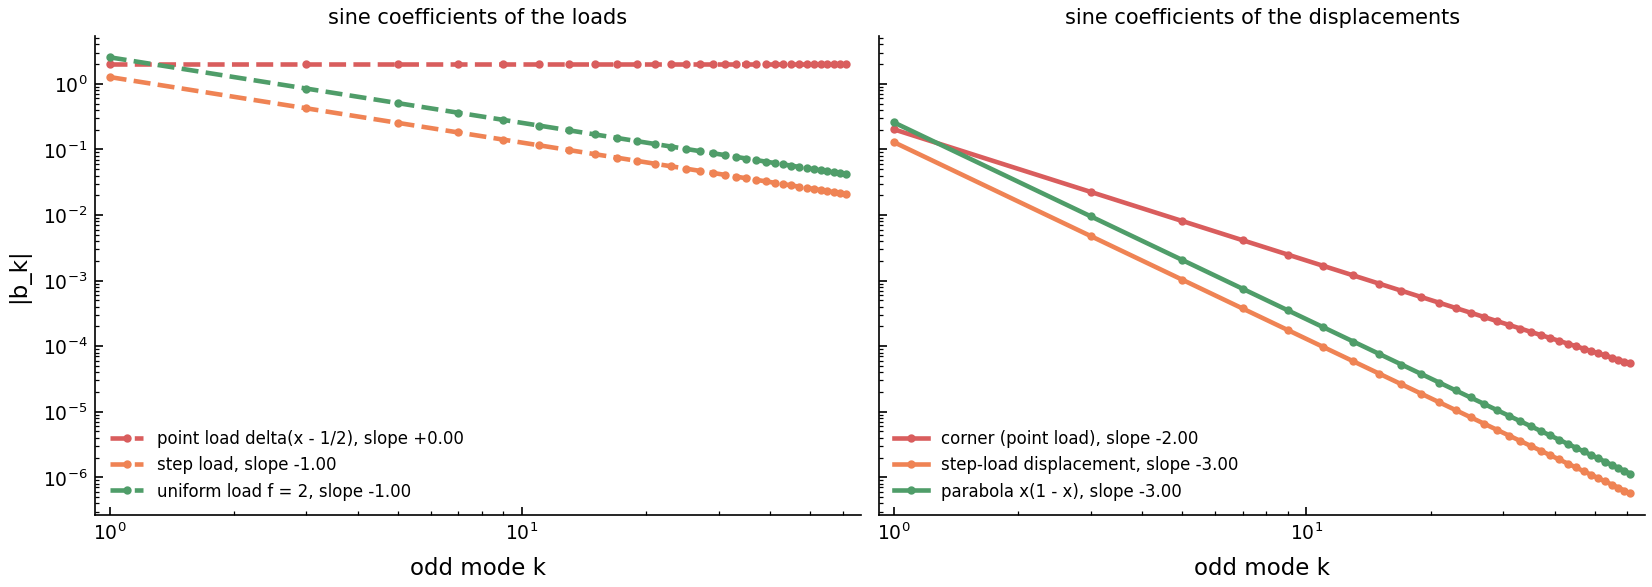

In [7]:
f_step = np.where(x < 0.5, 2.0, 0.0)
u_step = np.where(x <= 0.5, -x**2 + 0.75 * x, (1 - x) / 4)
left, right = x <= 0.5, x >= 0.5
print(f"step load: u(1/2) from the two pieces = {-0.25 + 0.375:.4f}, {0.5/4:.4f}; "
      f"u'(1/2) = {-2*0.5 + 0.75:.4f}, {-0.25:.4f}")
h = x[1] - x[0]
d2 = (u_step[2:] - 2 * u_step[1:-1] + u_step[:-2]) / h**2
away = np.abs(x[1:-1] - 0.5) > 2 * h
print(f"step load: max |u'' + f| away from x = 1/2 = {np.max(np.abs(d2 + f_step[1:-1])[away]):.1e}")
print(f"step load: ||u''||_L2 = ||f||_L2 = {l2(f_step):.4f}")
v = np.minimum(x, 1 - x) / 2
print(f"corner: v(1/2) = {v[len(x)//2]:.4f}, sqrt(1/2) |v|_H1 = {np.sqrt(0.5) * 0.5:.4f}")

ks = np.arange(1, 62, 2)                     # odd modes; the fit uses k >= 5
fit = ks >= 5
series = {
    "point load delta(x - 1/2)": (np.abs(2 * np.sin(ks * np.pi / 2)), RED, "--"),
    "step load": (np.abs([sine_coeff(f_step, k) for k in ks]), ORANGE, "--"),
    "uniform load f = 2": (np.abs([sine_coeff(2 + 0 * x, k) for k in ks]), GREEN, "--"),
    "corner (point load)": (np.abs([sine_coeff(np.minimum(x, 1 - x) / 2, k) for k in ks]), RED, "-"),
    "step-load displacement": (np.abs([sine_coeff(u_step, k) for k in ks]), ORANGE, "-"),
    "parabola x(1 - x)": (np.abs([sine_coeff(x * (1 - x), k) for k in ks]), GREEN, "-"),
}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
for i, (name, (b, col, ls)) in enumerate(series.items()):
    s = np.polyfit(np.log(ks[fit]), np.log(b[fit]), 1)[0]
    print(f"{name:28s} decay exponent = {s:+.2f}")
    ax[0 if i < 3 else 1].loglog(ks, b, ls, color=col, lw=2.2, marker="o", ms=3, label=f"{name}, slope {s:+.2f}")
ax[0].set_title("sine coefficients of the loads", fontsize=10)
ax[1].set_title("sine coefficients of the displacements", fontsize=10)
for a in ax:
    a.set_xlabel("odd mode k")
    a.legend(frameon=False, fontsize=8, loc="lower left")
ax[0].set_ylabel("|b_k|")
plt.show()

## Summary

| Space | Norm | What it controls | What it excludes | Where the chapter uses it |
|---|---|---|---|---|
| $L^2(0,1)$ | $\left(\int_0^1 f^2 \, dx\right)^{1/2}$ | mean-square size of the values | $x^{-1/2}$, and any meaning for a value at one point | error of a representation, projection onto modes |
| $H^1(0,1)$ | $\left(\int_0^1 (u^2 + u'^2) \, dx\right)^{1/2}$ | values and slopes, continuity in one dimension | the step, whose derivative is a delta | weak derivatives, point values |
| $H^1_0(0,1)$ | $\left(\int_0^1 u'^2 \, dx\right)^{1/2}$ | elastic energy of a pinned string | $u = x$, which is not pinned at $x = 1$ | the string's displacements, sensor readings |
| $H^2 \cap H^1_0$ | $\left(\int_0^1 u''^2 \, dx\right)^{1/2}$ | curvature | the corner, whose curvature is a delta | displacements under square-integrable loads |

The [Norms](norms.html) notebook measures errors in the sup, $L^2$, and $H^1$ norms, and the [Projection](projection.html) notebook finds closest approximations with the $L^2$ inner product.
In Chapter 2 these spaces appear in the sections on norms and the meaning of error, on inner products, projection, and orthogonality, and on convergence, density, and completeness.
